In [1]:
import numpy as np 
from matplotlib import pyplot as plt
plt.rcParams.update({'font.size': 16})
import pandas as pd
import random as rand

In [2]:
#soil moisture loss function
def loss_func (ET_max,ET_w,n,Zr,sh,sw,s1,sfc,ss):
    if (ss <= sh):
        losses = 0
    elif ((ss > sh) and (ss <= sw)):
        losses = (ET_w/(n*Zr))*((ss-sh)/(sw-sh))
    elif ((ss > sw) and (ss <= s1)):
        losses = (ET_w + (ET_max - ET_w)*((ss-sw)/(s1-sw)))/(n*Zr)
    elif ((ss > s1) and (ss <= sfc)):
        losses = (ET_max/(n*Zr))
    else:
        losses = (ET_max/(n*Zr))+(1/(n*Zr))*(Ks/(np.exp(beta*(1-sfc))-1) * ((np.exp(beta*(ss-sfc))) - 1 ))
        
    return losses

# Soil Properties
def soil(x):
    if x == "loamy sand":
        n = 0.42 # soil porosity [-],
        Zr = 30 # Depth of the rooting zone [cm]
        ET_max = 0.45 # maximum value of ET [cm/day]
        ET_w = 0.01 #  value of ET [mm/day] at wilting point
        phis = -0.17*10**-3 #(MPa)
        b = 4.38
        sfc = 0.52 # soil moisture at field capacity
        sw = 0.11 # wilting point
        sh = (phis/-10000)**(1/b) # soil moisture at hygroscopic point
        swh = (phis/-100)**(1/b)
        s1 = 0.31 # soil moisture at onset of plant stress
        beta = 12.7 # soil term to calculate K(s) decay as part of leakage term
        Ks = 100 # saturated hydraulic conductivity of the soil [K(ss=1)] (cm/day)        
        nn = 0.1362 # Normalization constant, so f[s] max =1
        km = 0.03    #(*microbial deposition rate*)
        hh = 0.92     #(*Influence of temperature on bacteria metabolism, Ehhalt and Roher(2011)*)
        sopt = (phis/-0.3)**(1/b)
        beta1 = 0.4
        beta2 = beta1*((1-sopt)/(sopt-swh))
        beta22 = beta1*((1-sopt)/(sopt-sw))
        
    elif x == "sand":
        n = 0.35 # soil porosity [-],
        Zr = 30 # Depth of the rooting zone [cm]
        ET_max = 0.45 # maximum value of ET [cm/day]
        ET_w = 0.01 #  value of ET [cm/day] at wilting point
        phis = -0.34*10**-3 #(MPa)
        b = 4.05
        sfc = 0.35 # soil moisture at field capacity
        sw = 0.11 # wilting point
        sh = (phis/-10000)**(1/b) # soil moisture at hygroscopic point
        swh = (phis/-100)**(1/b)
        s1 = 0.33 # soil moisture at onset of plant stress
        beta = 12.1 # soil term to calculate K(s) decay as part of leakage term
        Ks = 200 # saturated hydraulic conductivity of the soil [K(ss=1)] (cm/day)        
        nn = 0.154 # Normalization constant, so f[s] max =1
        km = 0.03    #(*microbial deposition rate*)
        hh = 0.92     #(*Influence of temperature on bacteria metabolism, Ehhalt and Roher(2011)*)
        sopt = (phis/-0.3)**(1/b)
        beta1 = 0.4
        beta2 = beta1*((1-sopt)/(sopt-swh))
        beta22 = beta1*((1-sopt)/(sopt-sw))
        
    elif x == "loam":
        n = 0.45 # soil porosity [-],
        Zr = 30 # Depth of the rooting zone [cm]
        ET_max = 0.45 # maximum value of ET [cm/day]
        ET_w = 0.01 #  value of ET [cm/day] at wilting point
        phis = -1.43*10**-3 #(MPa)
        b = 5.39
        sfc = 0.65 # soil moisture at field capacity
        sw = 0.24 # wilting point
        sh = (phis/-10000)**(1/b) # soil moisture at hygroscopic point
        swh = (phis/-100)**(1/b)
        s1 = 0.57 # soil moisture at onset of plant stress
        beta = 13.8 # soil term to calculate K(s) decay as part of leakage term
        Ks= 20 # saturated hydraulic conductivity of the soil [K(ss=1)] (cm/day)
        nn = 0.18 # Normalization constant, so f[s] max =1
        km = 0.03    #(*microbial deposition rate*)
        hh = 0.92     #(*Influence of temperature on bacteria metabolism, Ehhalt and Roher(2011)*)
        sopt = (phis/-0.3)**(1/b)
        beta1 = 0.4
        beta2 = beta1*((1-sopt)/(sopt-swh))
        beta22 = beta1*((1-sopt)/(sopt-sw))
        
    elif x == "sandy loam":
        n = 0.43 # soil porosity [-],
        Zr = 30 # Depth of the rooting zone [cm]
        ET_max = 0.45 # maximum value of ET [cm/day]
        ET_w = 0.01 #  value of ET [cm/day] at wilting point
        phis = -0.7*10**-3 #(MPa)
        b = 4.9
        sfc = 0.56 # soil moisture at field capacity
        sw = 0.18 # wilting point
        sh = (phis/-10000)**(1/b) # soil moisture at hygroscopic point
        swh = (phis/-100)**(1/b)
        s1 = 0.46 # soil moisture at onset of plant stress
        beta = 12.8 # soil term to calculate K(s) decay as part of leakage term
        Ks= 80 # saturated hydraulic conductivity of the soil [K(ss=1)] (cm/day)
        nn = 0.18 # Normalization constant, so f[s] max =1
        km = 0.03    #(*microbial deposition rate*)
        hh = 0.92     #(*Influence of temperature on bacteria metabolism, Ehhalt and Roher(2011)*)
        sopt = (phis/-0.3)**(1/b)
        beta1 = 0.4
        beta2 = beta1*((1-sopt)/(sopt-swh))
        beta22 = beta1*((1-sopt)/(sopt-sw))    
    else:
        pass
    return n, b, Zr, ET_max, ET_w, sfc, sw, sh,swh, s1, beta, Ks, nn, km, hh, beta1,sopt, beta2, beta22

# Response of biotic H2 consuming bacteria to soil moisture 
def fh(ss):
    if ss <= swh:
        fs=0
    else:
        fs = (((ss-swh)**beta1)*((1-ss)**beta2))/(((sopt-swh)**beta1)*((1-sopt)**beta2))
    return fs

def fhm(ss):
    if ss <= sw:
        fs=0
    else:
        fs = (((ss-sw)**beta1)*((1-ss)**beta22))/(((sopt-sw)**beta1)*((1-sopt)**beta22))
    return fs

# Response of Organic Carbon consuming bacteria to soil moisture
def fc(ss):
    if ss <= sw:
        fs=0
    elif sw < ss <= sfc:
        fs = (ss - sw)/(sfc - sw)
    else:
        fs = sfc/ss
    return fs
    
#total conductance of the soil and diffusive barrier
def gt(s,d,sp):
    D0 = 0.756
    a1 = 1 #alpha1
    a2 = 2 #alpha2
    a3 = 2+3/b
    gs = D0 * a1 * (n**a2) * (1-s)**a3
    gd = D0 * a1 * (sp**a2)/d
    #gt = ((n**2)*((1-ss)**(2+3/4.38))*(0.5**2)*0.756)/((n**2)*((1-ss)**(2+3/4.38)) +(0.5**2))
    gt = (gs * gd)/(gs + gd)
    return gt

# H2 Diffusive flux
def ff(ss,H):
    ff = gt(ss, d, sp)*(Ha-H)
    return ff

# h2 biological sink
def bd(s, Cs, Bh):
    bd = hh*khh*fh(s)*Cs*Bh
    return bd

# Velocity that indicates the potential bological sink along depth Zr
def vbd(s, Cs, Bh):
    vbd = Zr*bd(s, Cs, Bh)
    return vbd
# Quasi steady approximation of H2 conecntration in the soil
def hyd(s, Cs, Bh):
    hyd = Ha/(1 + (vbd(s, Cs, Bh)/gt(s, d, sp)))
    return hyd


def rainfall(y):
    alpha_p = 1.5 # average precipitation per event[cm]
    rainfall_ = np.zeros(int(length/dt))
    for i in range(0, int(length/dt)):
        r = np.random.default_rng().exponential(y)
        if r < y*dt:
            rainfall_[i] = np.random.default_rng().exponential(alpha_p/(n*Zr))
        else:
            rainfall_[i] = 0
    return rainfall_

In [3]:
n, b, Zr, ET_max, ET_w, sfc, sw, sh,swh, s1, beta, Ks, nn, km, hh, beta1,sopt, beta2, beta22 = soil("loamy sand")

In [4]:
length = 7300 # simulation time (days)
s0 = 0.5 # Soil moisture at the beginnig of the simulation [-]
Ha = 530  #(*Atmospheric concentration of hydrogen* ppb)
dt = 0.001 # time interval (days)
time = np.linspace(0,length-dt,int(length/dt))


In [5]:
rain_vec = np.zeros(int(length/dt))
for i in range(0, int(length/dt), int(60/dt)):
    rain_vec[i] = 2/(n*Zr) # 2 or 3.5, value for h_0

In [6]:
def run_ss(x):
    ss_vec = x.copy()
    for i in range(1, int(length/dt)):
        loss =  loss_func(ET_max,ET_w,n,Zr,sh,sw,s1,sfc,ss_vec[i-1])
        ss_vec[i] = ss_vec[i-1] + rain_vec[i] - dt*loss
        if ss_vec[i]>=1:
            ss_vec[i] = 0.99
        else:
            pass    
    return ss_vec

In [7]:
ADD_max = 3.2 #g/m3/day
ADD_min = 0 #g/m3/day
khh = 3.2*10**-4 # Potential decomposition rate for hydrogen
kcc = 1.8*10**-3 # Potential decomposition rate for carbon
mc = 0.005 # Mortality rate for carbon microbes
mh = 0.005 # Mortality rate for Hydrogen microbes
rc = 0.6 # Respiration rate for Carbon microbes
rh = 0.6 # Respiration rate for Hydrogen microbes
q = 12*0.0072 # carbon to hydrogen ratio [C/H]

def ADD(s):
    ADD = ADD_max + (ADD_min - ADD_max)/(1 + (s/sfc)**3.31)
    return ADD

def substrate_sol(i):
    # Dormancy condition
    if ss[i] <= sw:
        eta = 0
        mh = 0.00005 # Mortality rate for Hydrogen microbes
    else:
        eta = 1
        mh = 0.005 # Mortality rate for Hydrogen microbes
    kc = kcc*hh*fc(ss[i-1])
    kh = khh*hh*fh(ss[i-1])
    DEC_c = kc*Cs[i-1]*Bc[i-1]
    DEC_h = eta*q*kh*Cs[i-1]*Bh[i-1]*H[i-1]*n*(1-ss[i-1])
    BD_c = mc*Bc[i-1]
    BD_h = mh*Bh[i-1]
    cs = Cs[i-1] + dt*(ADd - DEC_c - DEC_h + BD_c + BD_h)
    return cs

def Microbe_c(i):
    kc = kcc*hh*fc(ss[i-1])
    DEC_c = kc*Cs[i-1]*Bc[i-1]
    BD_c = mc*Bc[i-1]
    bc = Bc[i-1] + dt*((1-rc)*DEC_c - BD_c)
    return bc

def Microbe_h(i):
    # Dormancy condition
    if ss[i] <= sw:
        eta = 0
        mh = 0.00005 # Mortality rate for Hydrogen microbes
    else:
        eta = 1
        mh = 0.005 # Mortality rate for Hydrogen microbes
    kh = khh*hh*fh(ss[i-1])
    DEC_h = eta*q*kh*Cs[i-1]*Bh[i-1]*H[i-1]*n*(1-ss[i-1])
    BD_h = mh*Bh[i-1]
    bh = Bh[i-1] + dt*((1-rh)*DEC_h - BD_h)
    return bh

def run_hyd(i):
    flux = ff(ss[i-1], H[i-1])
    b_d = bd(ss[i-1], Cs[i-1], Bh[i-1])*H[i-1]*Zr
    air = 1 - ss[i-1]
    H_vec = H[i-1] + ((flux - b_d))/(n*Zr*air) + H[i-1]*(ss[i] - ss[i-1])/air
    if H_vec > Ha:
        H_vec = Ha
    return H_vec

Cs = np.zeros(int(length/dt))
Cs[0] = 80
Bc = np.zeros(int(length/dt))
Bc[0] = 5
Bh = np.zeros(int(length/dt))
Bh[0] = 1
ss_vec = np.zeros(int(length/dt))
ss_vec[0] = 0.99
d = 1
sp = 0.5
hyd_vec = np.zeros(int(length/dt)) #Quasi steady approximation
hyd_vec[0] = hyd(s0, Cs[0], Bh[0])
H = np.zeros(int(length/dt))
H[0] = hyd_vec[0]

In [21]:
def ADD(s):
    ADD = ADD_max + (ADD_min - ADD_max)/(1 + (s/sfc)**3.31)
    return ADD

def substrate_sol1(i):
    kc = kcc*hh*fc(ss[i-1])
    kh = khh*hh*fh(ss[i-1])
    DEC_c = kc*Cs1[i-1]*Bc1[i-1]
    DEC_h = q*kh*Cs1[i-1]*Bh1[i-1]*H1[i-1]*n*(1-ss[i-1])
    BD_c = mc*Bc1[i-1]
    BD_h = mh*Bh1[i-1]
    cs = Cs1[i-1] + dt*(ADd - DEC_c - DEC_h + BD_c + BD_h)
    return cs

def Microbe_c1(i):
    kc = kcc*hh*fc(ss[i-1])
    DEC_c = kc*Cs1[i-1]*Bc1[i-1]
    BD_c = mc*Bc1[i-1]
    bc = Bc1[i-1] + dt*((1-rc)*DEC_c - BD_c)
    return bc

def Microbe_h1(i):
    kh = khh*hh*fh(ss[i-1])
    DEC_h = q*kh*Cs1[i-1]*Bh1[i-1]*H1[i-1]*n*(1-ss[i-1])
    BD_h = mh*Bh1[i-1]
    bh = Bh1[i-1] + dt*((1-rh)*DEC_h - BD_h)
    return bh

def run_hyd1(i):
    flux = ff(ss[i-1], H1[i-1])
    b_d = hh*khh*fh(ss[i-1])*Cs1[i-1]*Bh1[i-1]*H1[i-1]*Zr
    air = 1 - ss[i-1]
    H_vec = H1[i-1] + (flux - b_d)/(n*Zr*air) + H1[i-1]*(ss[i] - ss[i-1])/air
    if H_vec > 530:
        H_vec = 530
    return H_vec
def hyd1(s, Cs, Bh):
    hyd = Ha/(1 + (hh*khh*fh(s)*Cs*Bh*Zr)/gt(s, d, sp))
    return hyd

def vbdn(s, Cs, Bh):
    vbd = Zr*hh*khh*fh(s)*Cs*Bh
    return vbd

Cs1 = np.zeros(int(length/dt))
Cs1[0] = 80
Bc1 = np.zeros(int(length/dt))
Bc1[0] = 5
Bh1 = np.zeros(int(length/dt))
Bh1[0] = 1

hyd_vec1 = np.zeros(int(length/dt)) #Quasi steady approximation
hyd_vec1[0] = hyd1(s0, Cs1[0], Bh1[0])
H1 = np.zeros(int(length/dt))
H1[0] = hyd_vec1[0]

In [10]:
%%time
ss = run_ss(ss_vec)
ADd = ADD(np.mean(ss))
for i in range(1, int(length/dt)):
    Bc1[i] = Microbe_c1(i)
    Cs1[i] = substrate_sol1(i)
    Bh1[i] = Microbe_h1(i)
    H1[i] = run_hyd1(i)
    hyd_vec1[i] = hyd1(ss[i], Cs1[i], Bh1[i])

CPU times: user 8.59 s, sys: 10.3 ms, total: 8.6 s
Wall time: 8.62 s


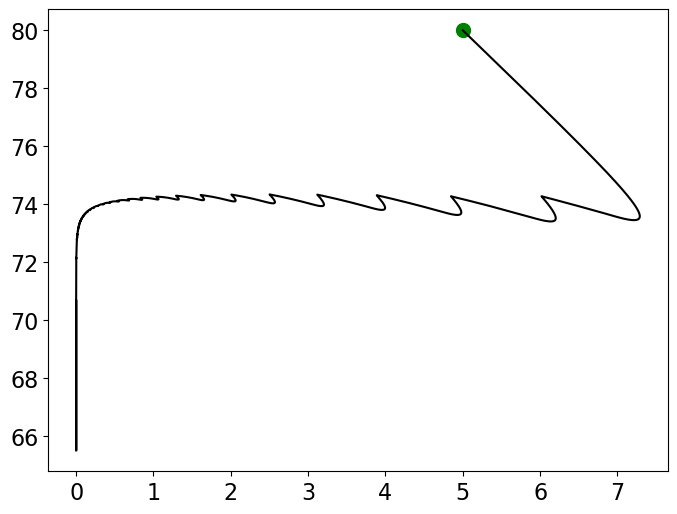

In [34]:
plt.figure(figsize=(8,6))
#plt.plot(BC1, CS1, color="k")
plt.plot(Bc1, Cs1, color="k")
plt.scatter(Bc1[1], Cs1[1], color = "green", s=10**2);

In [14]:
def run_hyd2(i):
    flux = ff(ss[i-1], c[i-1])
    b_d = 0.03*fh(ss[i-1])*hh*c[i-1]*Zr
    air = 1 - ss[i-1]
    H_vec = c[i-1] + ((flux - b_d)/(n*Zr*air)) + c[i-1]*(ss[i] - ss[i-1])/air
    if H_vec > Ha:
        H_vec = Ha
    return H_vec

def hyd2(s):
    hyd = Ha/(1 + ((0.03*fh(s)*hh*Zr)/gt(s)))
    return hyd

c = np.zeros(int(length/dt))
c1 = np.zeros(int(length/dt))
c1[0] = hyd2(s0)
c[0] = c1[0]

for i in range(1, int(length/dt)):
    c[i] = run_hyd2(i)
    c1[i] = hyd2(ss[i])

In [5]:
df = pd.read_csv("dry+rewet.csv")

In [6]:
df_s_dry = df["s_dry"]
df_s_int = df["s_int"]
df_s_wet = df["s_wet"]
df_Bh_dry = df["Bh_dry"]
df_Bh_int = df["Bh_int"]
df_Bh_wet = df["Bh_wet"]
df_Cs_dry = df["Cs_dry"]
df_Cs_int = df["Cs_int"]
df_Cs_wet = df["Cs_wet"]
df_Bc_dry = df["Bc_dry"]
df_Bc_int = df["Bc_int"]
df_Bc_wet = df["Bc_wet"]
df_H_dry = df["H_dry"]
df_H_int = df["H_int"]
df_H_wet = df["H_wet"]

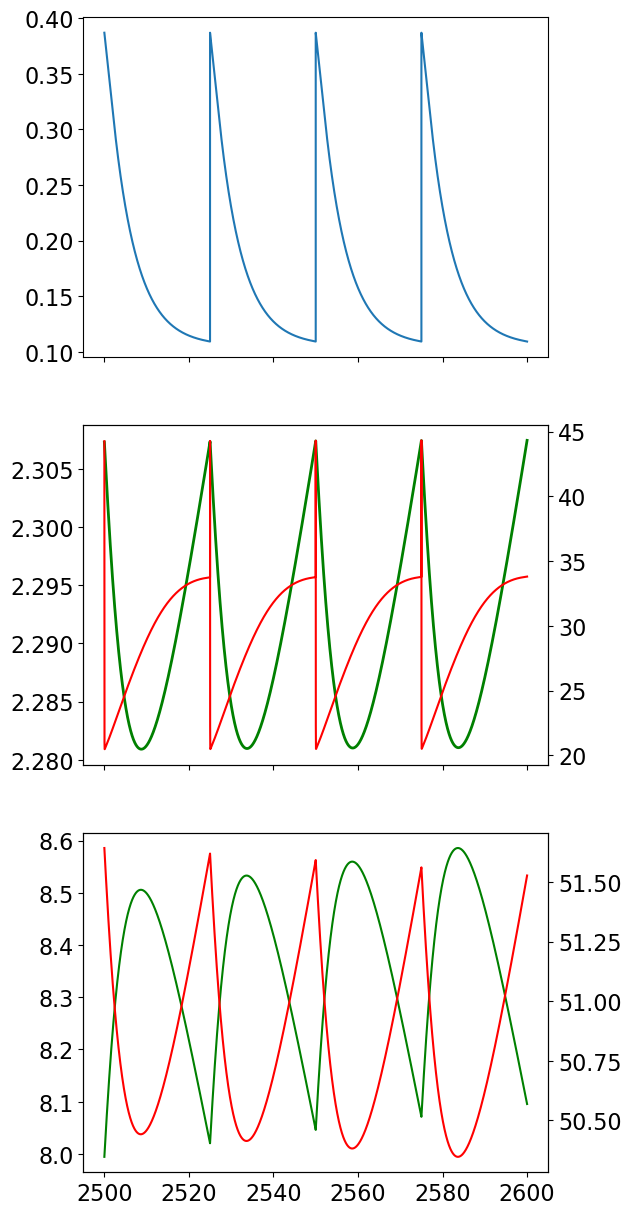

In [178]:
fig, axs = plt.subplots(3, 1, figsize=(6,15), sharex=True)
axs[0].plot(time[2500000:2600000], df["s_wet"][2500000:2600000])
axs[1].plot(time[2500000:2600000], df["Bh_wet"][2500000:2600000], color="green", linewidth=2)
ax2 = axs[1].twinx()
ax2.plot(time[2500000:2600000], df["H_wet"][2500000:2600000], color="red")
#ax2.plot(time[0:2000000], c[20000:2020000], color="black")
axs[2].plot(time[2500000:2600000], df["Bc_wet"][2500000:2600000], color="green")
ax1 = axs[2].twinx()
ax1.plot(time[2500000:2600000], df["Cs_wet"][2500000:2600000], color="red")

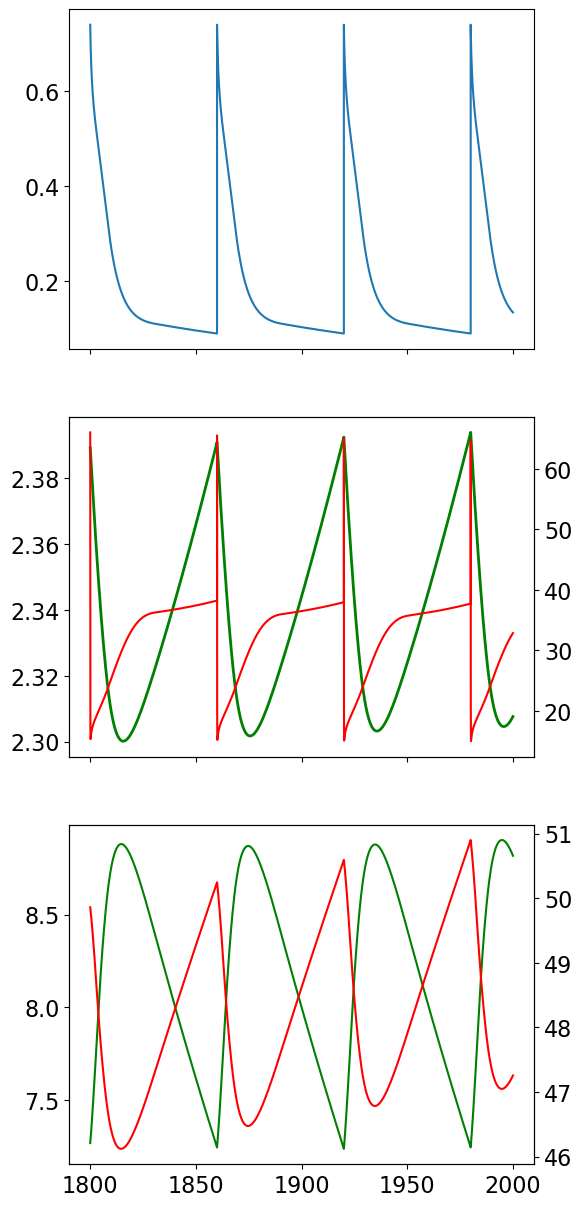

In [9]:
fig, axs = plt.subplots(3, 1, figsize=(6,15), sharex=True)
axs[0].plot(time[1800000:2000000], df["s_wet"][1800000:2000000])
axs[1].plot(time[1800000:2000000], df["Bh_wet"][1800000:2000000], color="green", linewidth=2)
ax2 = axs[1].twinx()
ax2.plot(time[1800000:2000000], df["H_wet"][1800000:2000000], color="red")
#ax2.plot(time[0:2000000], c[20000:2020000], color="black")
axs[2].plot(time[1800000:2000000], df["Bc_wet"][1800000:2000000], color="green")
ax1 = axs[2].twinx()
ax1.plot(time[1800000:2000000], df["Cs_wet"][1800000:2000000], color="red")

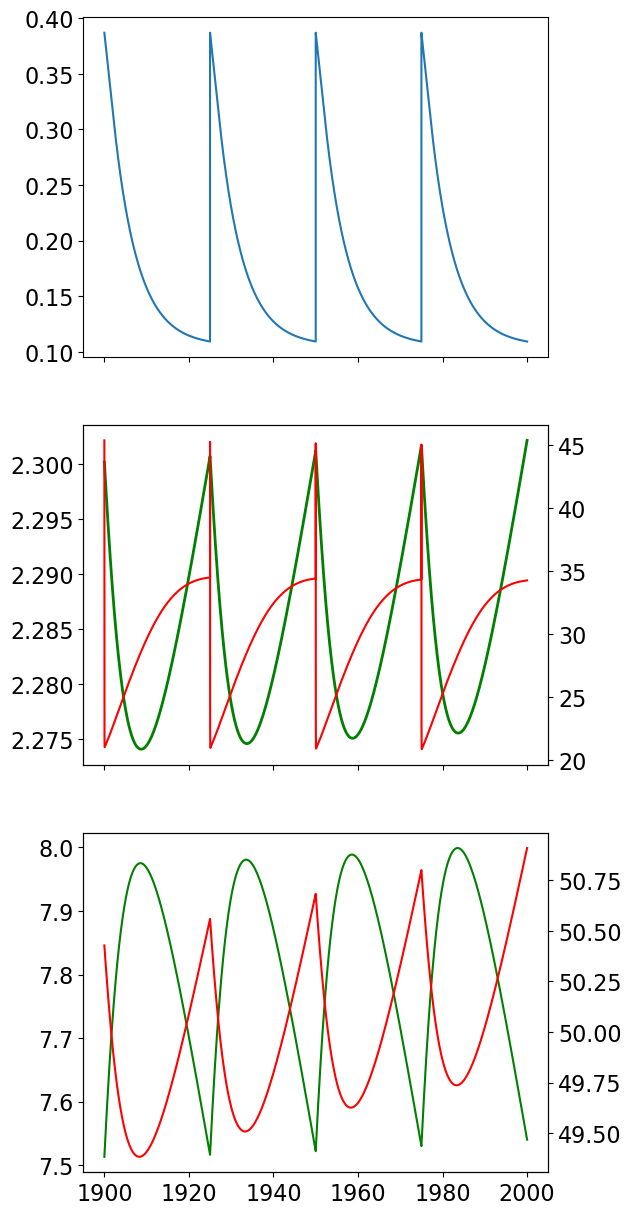

In [176]:
fig, axs = plt.subplots(3, 1, figsize=(6,15), sharex=True)
axs[0].plot(time[1900000:2000000], df["s_wet"][1900000:2000000])
axs[1].plot(time[1900000:2000000], df["Bh_wet"][1900000:2000000], color="green", linewidth=2)
ax2 = axs[1].twinx()
ax2.plot(time[1900000:2000000], df["H_wet"][1900000:2000000], color="red")
#ax2.plot(time[0:2000000], c[20000:2020000], color="black")
axs[2].plot(time[1900000:2000000], df["Bc_wet"][1900000:2000000], color="green")
ax1 = axs[2].twinx()
ax1.plot(time[1900000:2000000], df["Cs_wet"][1900000:2000000], color="red")

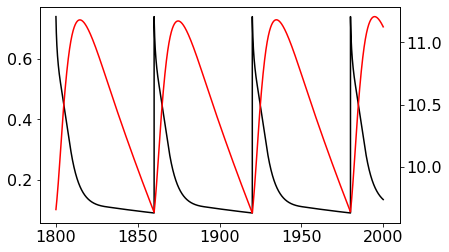

In [43]:
fig = plt.figure()
fig.set_figwidth(5)
fig.set_figheight(3)
ax1 = fig.add_axes([0,0,1,1])
ax1.plot(time[1800000:2000000], df["s_wet"][1800000:2000000], color="k")
#ax1.set_ylabel(r'$B_H$ $[gCm^{-3}]$', fontsize=18)
# labels along the bottom edge are off
ax2=ax1.twinx()
ax2.plot(time[1800000:2000000], df["Bh_wet"][1800000:2000000]+df["Bc_wet"][1800000:2000000], color = "red")
#ax2.set_ylabel(r'$\bar H$ $[ppb]$', fontsize=18)
#plt.legend(fontsize=12, loc="upper left")
plt.show();

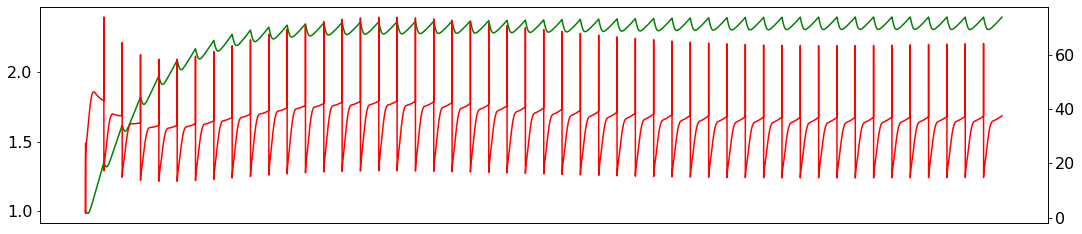

In [33]:
fig = plt.figure()
fig.set_figwidth(14)
fig.set_figheight(3)
ax1 = fig.add_axes([0,0,1,1])
ax1.plot(time[0:3000000], df["Bh_wet"][0:3000000], color="green")
#ax1.set_ylabel(r'$B_H$ $[gCm^{-3}]$', fontsize=18)
plt.tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=False) # labels along the bottom edge are off
ax2=ax1.twinx()
ax2.plot(time[0:3000000], df["H_wet"][0:3000000], color = "red")
#ax2.set_ylabel(r'$\bar H$ $[ppb]$', fontsize=18)
#plt.legend(fontsize=12, loc="upper left")
plt.tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=False) # labels along the bottom edge are off
plt.show();

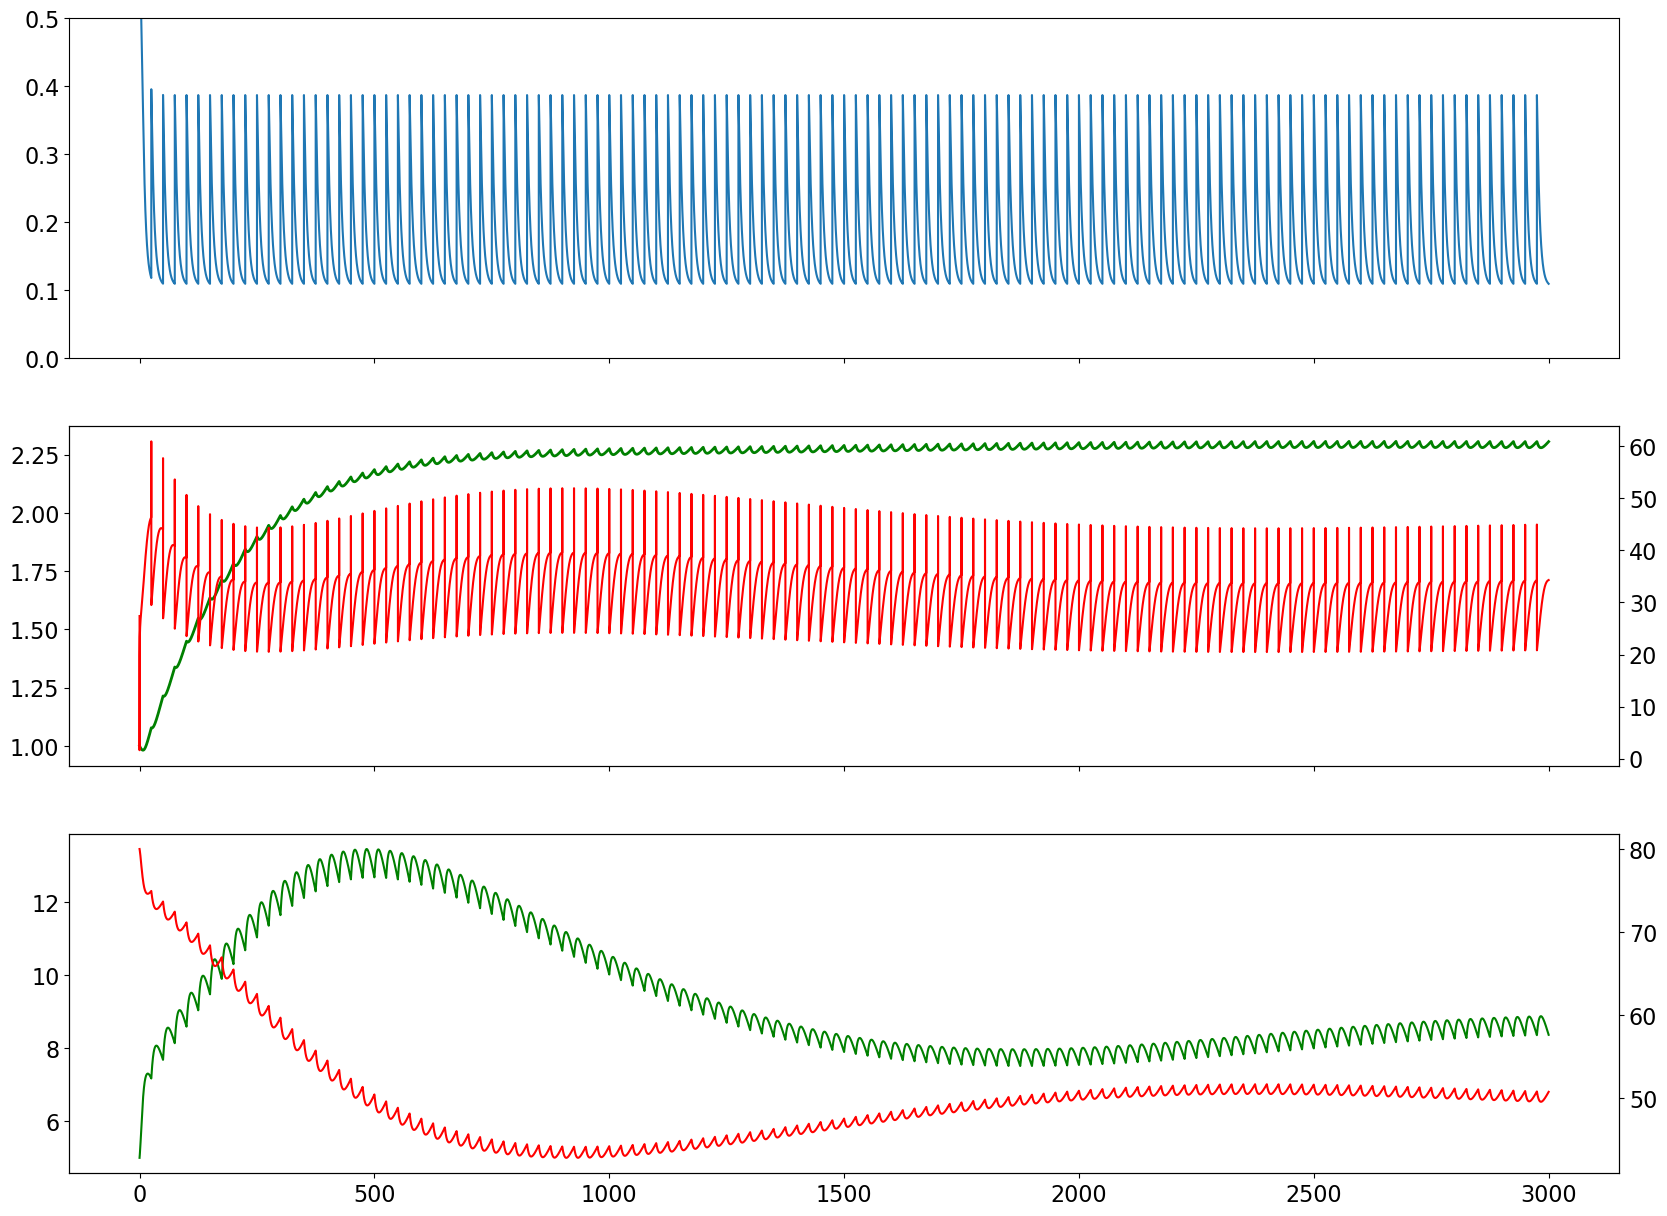

In [174]:
# Figure 3
fig, axs = plt.subplots(3, 1, figsize=(20,15), sharex=True)
axs[0].plot(time[0:3000000], df["s_wet"][0:3000000])
axs[0].set_ylim([0,0.5])
axs[1].plot(time[0:3000000], df["Bh_wet"][0:3000000], color="green", linewidth=2)
ax2 = axs[1].twinx()
ax2.plot(time[0:3000000], df["H_wet"][0:3000000], color="red")
#ax2.plot(time[0:2000000], c[20000:2020000], color="black")
axs[2].plot(time[0:3000000], df["Bc_wet"][0:3000000], color="green")
ax1 = axs[2].twinx()
ax1.plot(time[0:3000000], df["Cs_wet"][0:3000000], color="red")

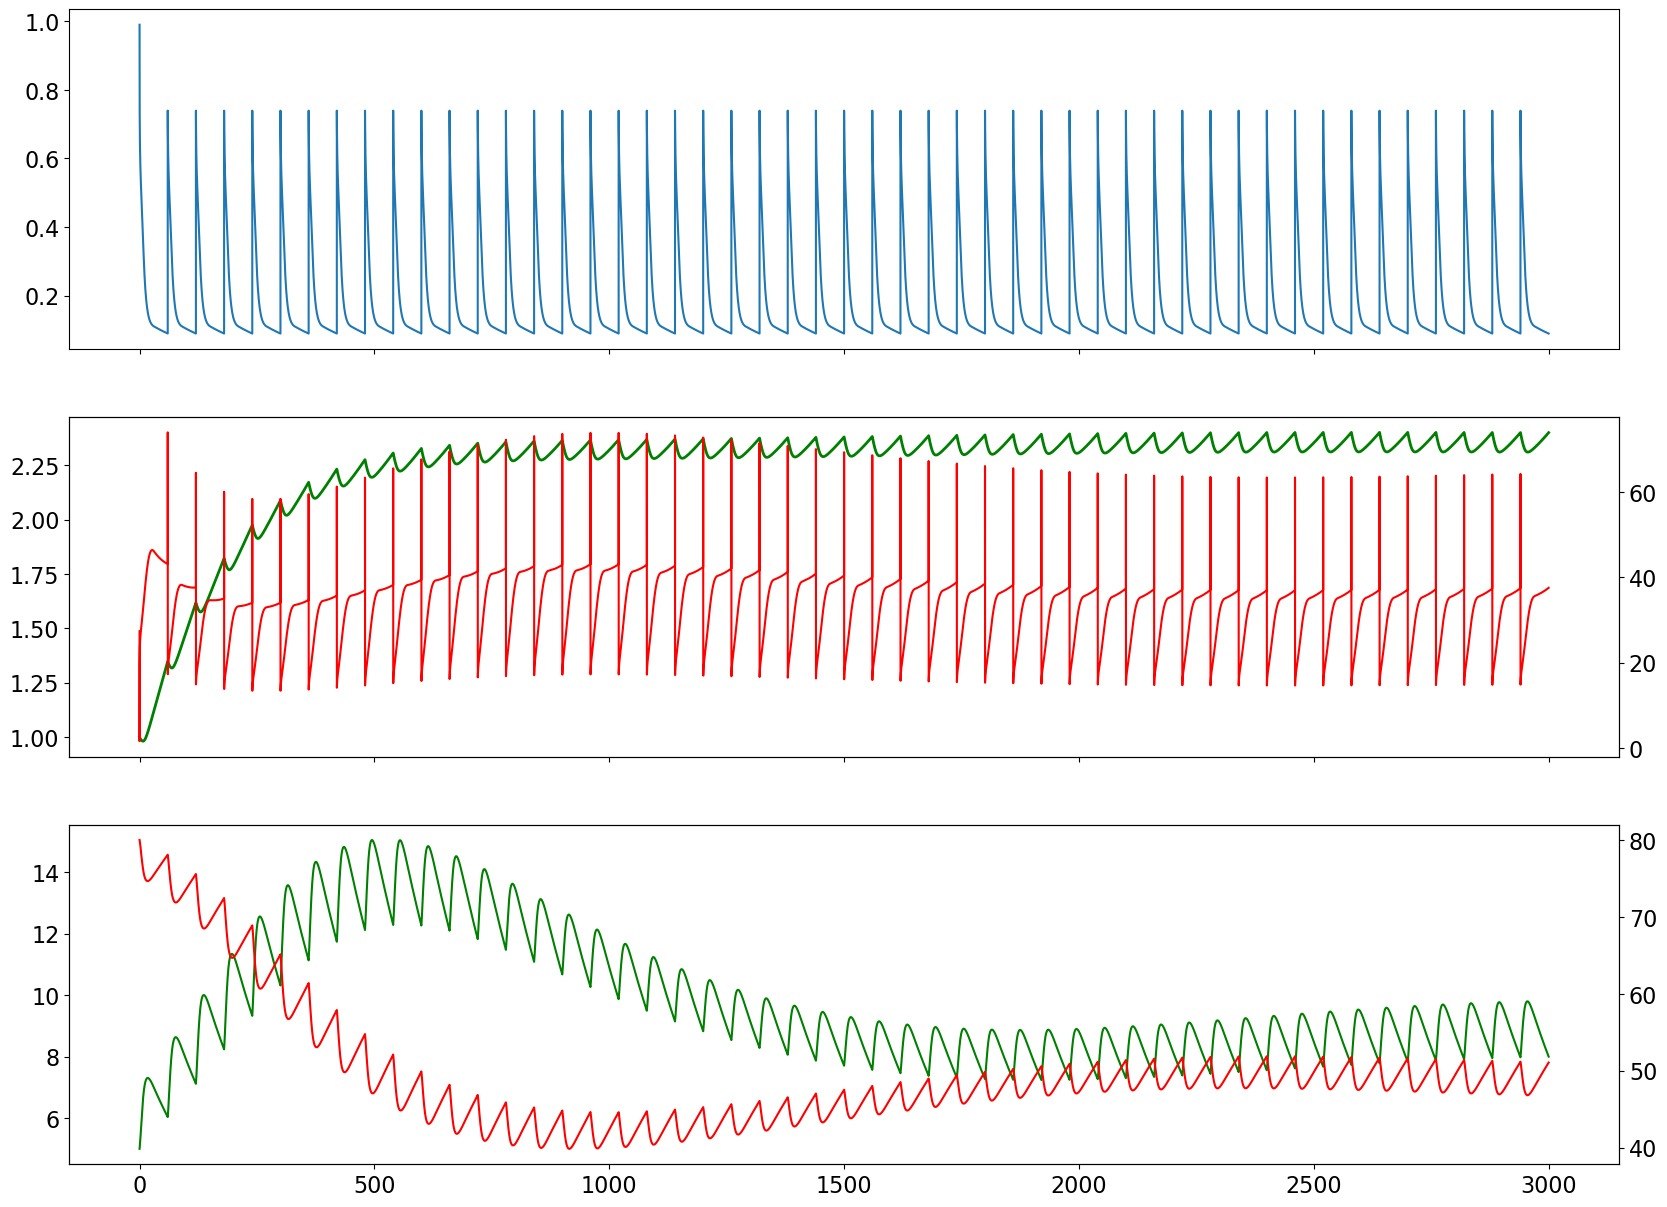

In [8]:
fig, axs = plt.subplots(3, 1, figsize=(20,15), sharex=True)
axs[0].plot(time[0:3000000], df["s_wet"][0:3000000])
axs[1].plot(time[0:3000000], df["Bh_wet"][0:3000000], color="green", linewidth=2)
ax2 = axs[1].twinx()
ax2.plot(time[0:3000000], df["H_wet"][0:3000000], color="red")
#ax2.plot(time[0:2000000], c[20000:2020000], color="black")
axs[2].plot(time[0:3000000], df["Bc_wet"][0:3000000], color="green")
ax1 = axs[2].twinx()
ax1.plot(time[0:3000000], df["Cs_wet"][0:3000000], color="red")

(-1.0, 15.0)

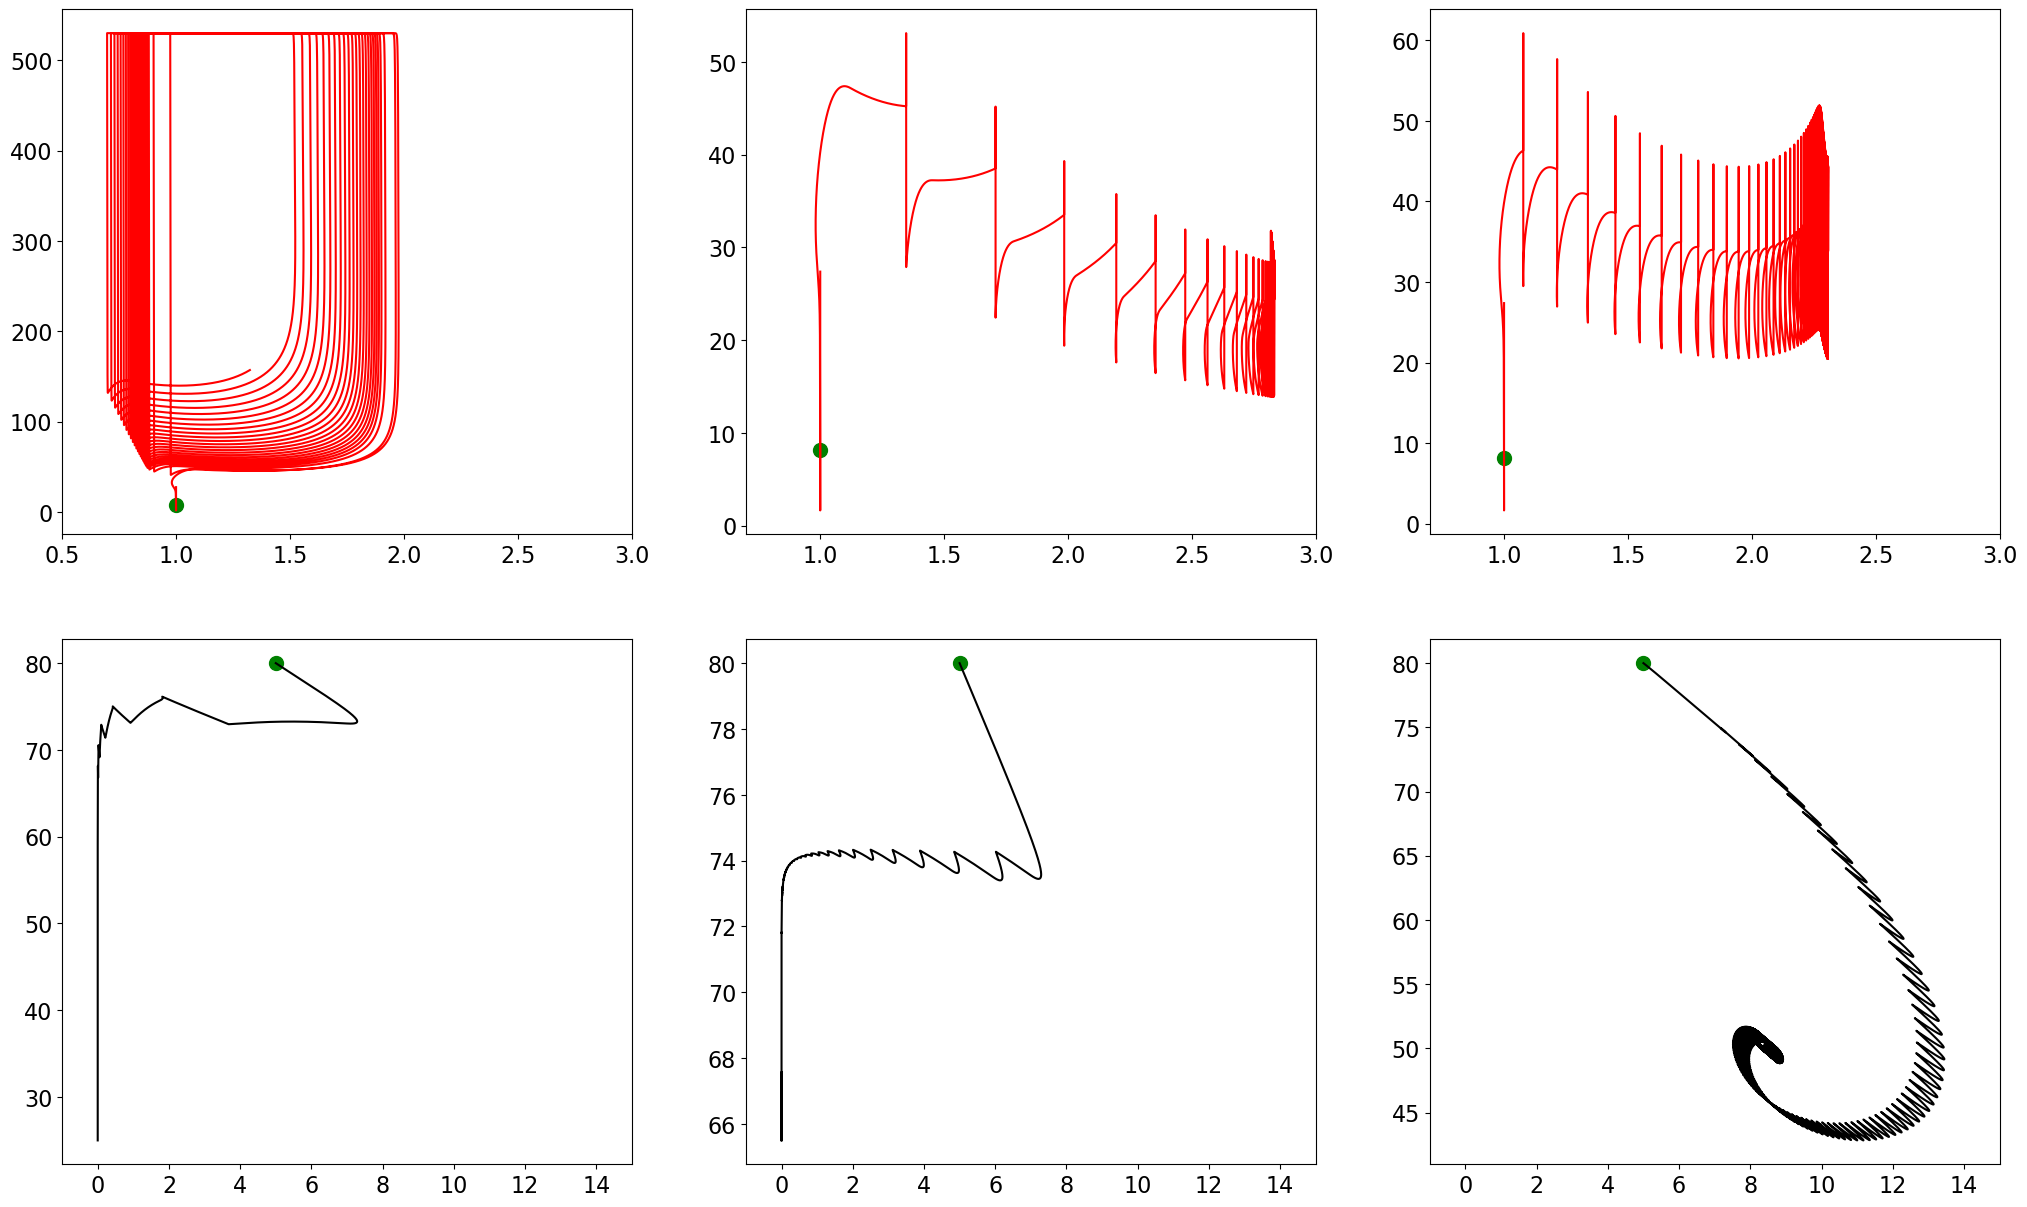

In [172]:
# Figure 4

fig, axs = plt.subplots(2, 3, figsize=(25,15))
axs[0,0].scatter(df["Bh_dry"][1], df["H_dry"][1], color="green", s=10**2)
axs[0,0].plot(df["Bh_dry"], df["H_dry"], color="red")
axs[0,0].set_xlim([0.5,3])
axs[0,1].scatter(df["Bh_dry"][1], df["H_dry"][1], color="green", s=10**2)
axs[0,1].plot(df["Bh_int"], df["H_int"], color="red")
axs[0,1].set_xlim([0.7,3])
axs[0,2].scatter(df["Bh_dry"][1], df["H_dry"][1], color="green", s=10**2)
axs[0,2].plot(df["Bh_wet"], df["H_wet"], color="red")
axs[0,2].set_xlim([0.7,3])
axs[1,0].scatter(df["Bc_dry"][1], df["Cs_dry"][1], color="green", s=10**2)
axs[1,0].plot(df["Bc_dry"], df["Cs_dry"], color="k")
axs[1,0].set_xlim([-1,15])
axs[1,1].scatter(df["Bc_dry"][1], df["Cs_dry"][1], color="green", s=10**2)
axs[1,1].plot(df["Bc_int"], df["Cs_int"], color="k")
axs[1,1].set_xlim([-1,15])
axs[1,2].scatter(df["Bc_dry"][1], df["Cs_dry"][1], color="green", s=10**2)
axs[1,2].plot(df["Bc_wet"], df["Cs_wet"], color="k")
axs[1,2].set_xlim([-1,15])

(-1, 15)

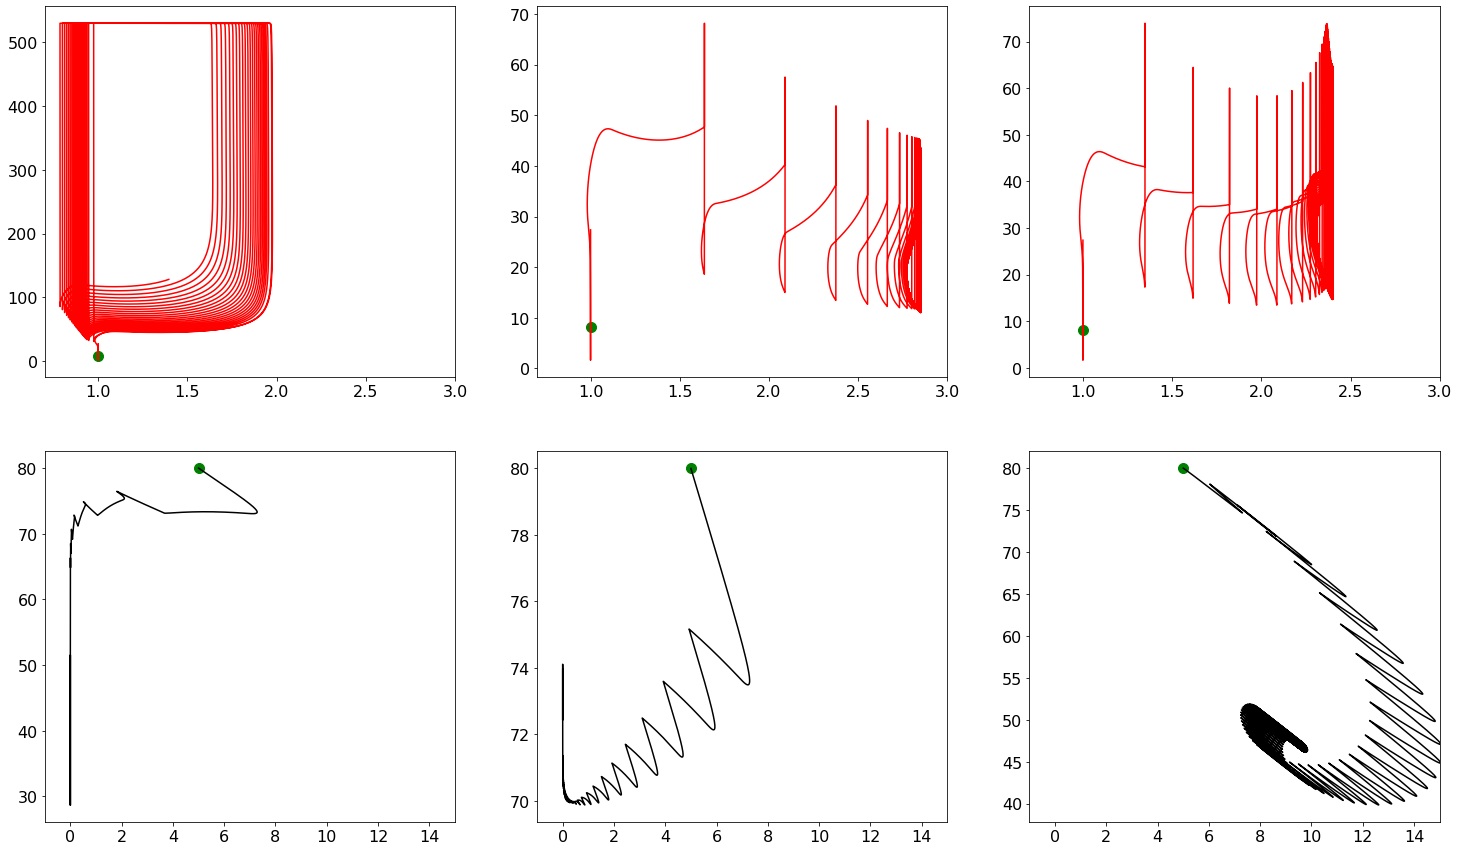

In [42]:
fig, axs = plt.subplots(2, 3, figsize=(25,15))
axs[0,0].scatter(df["Bh_dry"][1], df["H_dry"][1], color="green", s=10**2)
axs[0,0].plot(df["Bh_dry"], df["H_dry"], color="red")
axs[0,0].set_xlim([0.7,3])
axs[0,1].scatter(df["Bh_dry"][1], df["H_dry"][1], color="green", s=10**2)
axs[0,1].plot(df["Bh_int"], df["H_int"], color="red")
axs[0,1].set_xlim([0.7,3])
axs[0,2].scatter(df["Bh_dry"][1], df["H_dry"][1], color="green", s=10**2)
axs[0,2].plot(df["Bh_wet"], df["H_wet"], color="red")
axs[0,2].set_xlim([0.7,3])
axs[1,0].scatter(df["Bc_dry"][1], df["Cs_dry"][1], color="green", s=10**2)
axs[1,0].plot(df["Bc_dry"], df["Cs_dry"], color="k")
axs[1,0].set_xlim([-1,15])
axs[1,1].scatter(df["Bc_dry"][1], df["Cs_dry"][1], color="green", s=10**2)
axs[1,1].plot(df["Bc_int"], df["Cs_int"], color="k")
axs[1,1].set_xlim([-1,15])
axs[1,2].scatter(df["Bc_dry"][1], df["Cs_dry"][1], color="green", s=10**2)
axs[1,2].plot(df["Bc_wet"], df["Cs_wet"], color="k")
axs[1,2].set_xlim([-1,15])

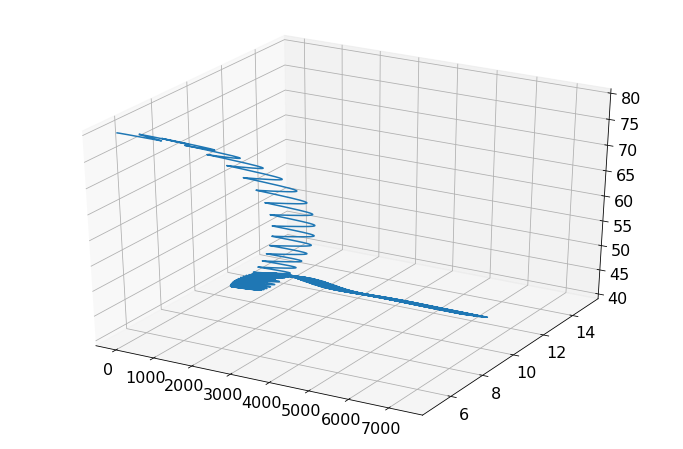

In [57]:
from mpl_toolkits import mplot3d
fig = plt.figure(figsize=(12,8))
ax = plt.axes(projection ='3d')
ax.plot3D(time, df["Bc_wet"], df["Cs_wet"])